## load data
read raw CSV and take first look at col types + missing values

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/telco_churn.csv')

print(df.shape)        
print(df.dtypes)
print(df.isnull().sum())


(7043, 21)
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod

## fix data quality issues
- `TotalCharges` looks numeric but stored as text; also 11 rows have blank string instead of number
- convert data properly and drop 11 blank rows
- also convert target column `Churn` from "Yes"/"No" text to 1s and 0s so the model can work with it

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Clean dataset: {df.shape[0]} rows remaining")

Clean dataset: 7032 rows remaining


## check class balance
- target is imbalanced, not every customer churns
- need to know ratio before choosing how to train model
(ratio worse than ~80/20 usually requires special handling)

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


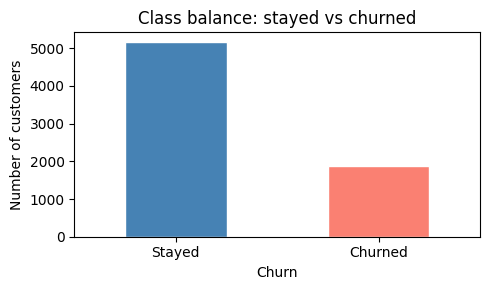

In [6]:
# % of customers actually churned
print(df['Churn'].value_counts(normalize=True))

df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'],
                                 edgecolor='white', figsize=(5, 3))
plt.xticks([0, 1], ['Stayed', 'Churned'], rotation=0)
plt.title('Class balance: stayed vs churned')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.show()

## explore 3 numeric features
- only have 3 numeric columns: `tenure` (months w company), `MonthlyCharges`, and `TotalCharges`
- plot their distributions to spot skew, outliers, or anything unexpected

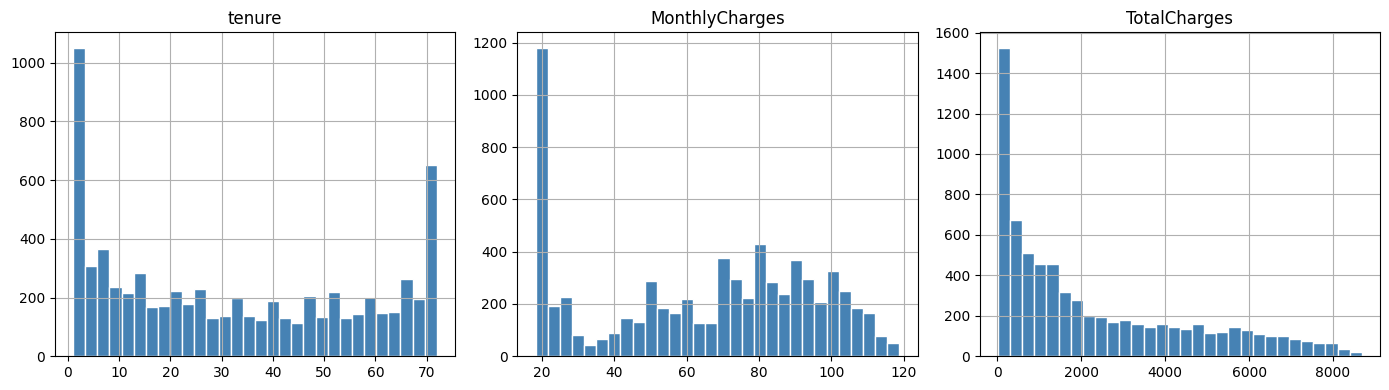

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    df[col].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
plt.tight_layout()
plt.savefig('../data/raw/numeric_distributions.png', dpi=120)
plt.show()

## which customer segments churn the most
- pick four cat. features and calculate avg churn rate in each group
- tells us which segments are highest risk
- gives us preview of what the model will likely flag as important

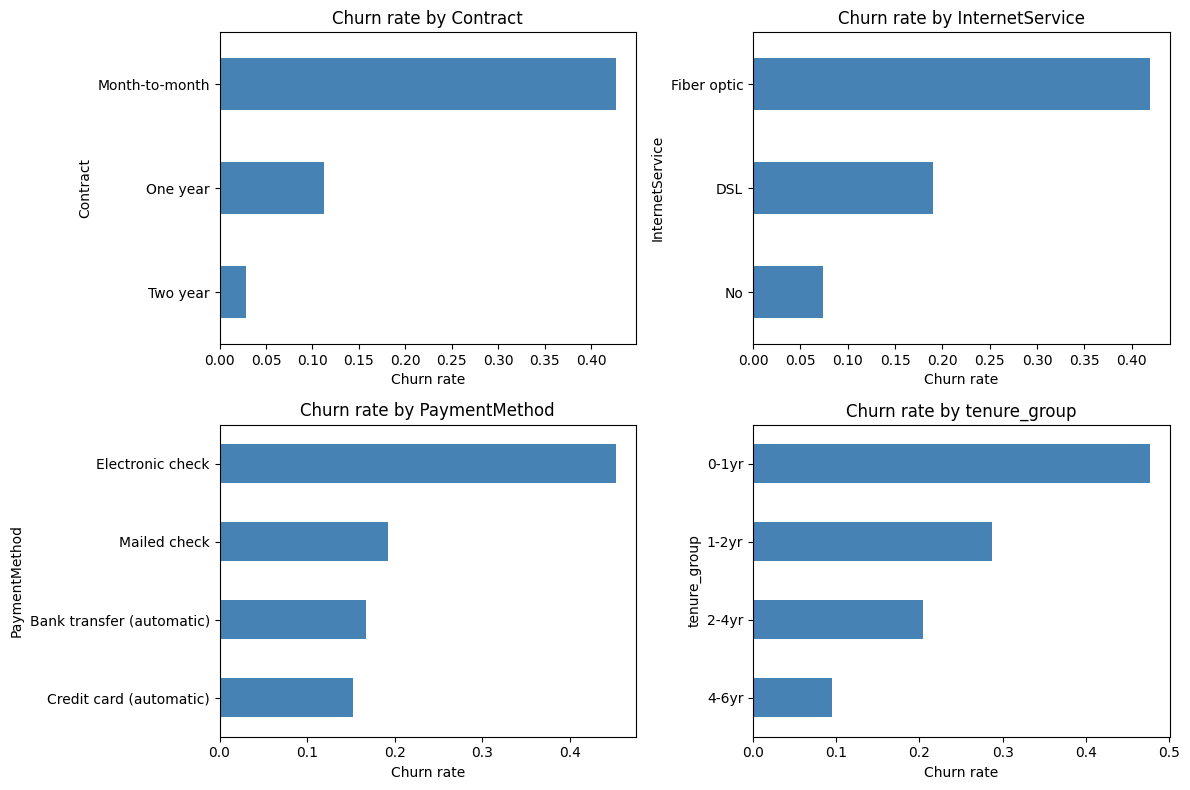

In [8]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72],
                             labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr'])

cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'tenure_group']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values()
    churn_rate.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Churn rate by {col}')
    ax.set_xlabel('Churn rate')
plt.tight_layout()
plt.show()

## how do numeric features correlate with churn?
- correlation heatmap shows if higher charges / longer tenure tend to go w churning or staying
- correlation only captures linear relationships 

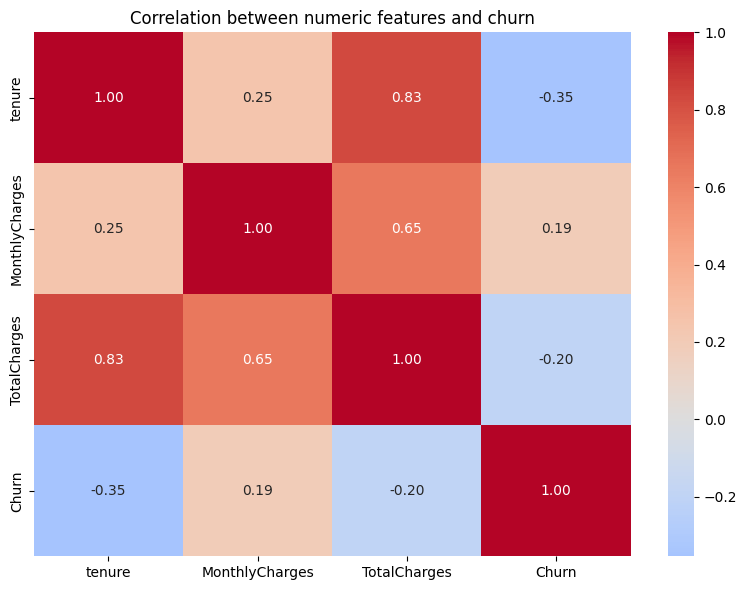

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm', center=0
)
plt.title('Correlation between numeric features and churn')
plt.tight_layout()
plt.show()